# Notebook \#5: Curve Simplification
#### by Sebastian Einar Salas Røkholt

---


**Index**  
- [**1 - Introduction and Setup**](#1---introduction-and-setup)  
  - [*1.1 Setup*](#11-setup)  
  - [*1.2 Load the Anomaly Detection Model*](#12-load-the-forecasting-model)  
  - [*1.3 Data Preparation*](#13-data-preparation)  
- [**2 - Chapter 2**](#2---chapter-2)  
  - [*2.1 ....*](#21-....)  

---

## 1 - Introduction and Setup
The aim of this notebook is to produce and plot an ORS simplification of a single charging session's power curve.
We tune the ORS terms/parameters on the validation set, then apply ORS to a test session.


## 1.1 Setup

In [2]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import lru_cache
import ipywidgets as widgets
from ipywidgets import Layout, HBox
from IPython.display import display, clear_output

# Modules from the project's MT4XAI package
%load_ext autoreload
%autoreload 2
from mt4xai.data import split_data, apply_scalers, build_loader, fit_scalers_on_train, fetch_session_preds_bundle
from mt4xai.model import load_lstm_model
from mt4xai.ors import ORSParams, ors, base_label_from_bundle
from mt4xai.plot import plot_raw_pred_simp_session
from mt4xai.inference import compute_session_MRMSE, classify_by_threshold, percentile_threshold

RANDOM_SEED = 42

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
CLEANED_DATA_PATH = os.path.join(PROJECT_ROOT, "Data", "etron55-charging-sessions.parquet")

FINAL_MODEL_FOLDER_PATH = os.path.join(PROJECT_ROOT, "Models/final")
FINAL_MODEL_PATH = os.path.join(FINAL_MODEL_FOLDER_PATH, "final_model.pth")


print("[env] CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("[env] Device:", torch.cuda.get_device_name(torch.cuda.current_device()))
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

%matplotlib inline

[env] CUDA available: True
[env] Device: NVIDIA GeForce RTX 4070 Laptop GPU


### 1.2 Load the Forecasting Model

In [3]:
# Loads a trained LSTM model from disk
model, checkpoint = load_lstm_model(FINAL_MODEL_PATH, device=DEVICE)

input_features  = checkpoint["input_features"]
target_features = checkpoint["target_features"]
cfg = checkpoint["config"]
HORIZON = int(cfg["horizon"])
POWER_WEIGHT = float(cfg.get("power_weight", 0.5))

# Indices of targets within the *input* feature vector (used for reconstruction)
idx_power_inp = input_features.index("power")
idx_soc_inp   = input_features.index("soc")

/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/src/mt4xai/model.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch

### 1.3 Data Preparation
In this section, we will load, transform, and split the data in exactly the same way as we did previously in order to extract the test set for running anomaly detection tests.

In [4]:
# Loads the cleaned data (already wrangled)
df_cleaned = pd.read_parquet(CLEANED_DATA_PATH)  # TODO: Replace with raw data and apply wrangling pipeline
# Removes features that aren't used to classify charging sessions
df = df_cleaned.drop(labels=['energy', 'charger_category', 'timestamp', 
                             'nearest_weather_station', 'timestamp_d', 'lat', 'lon', 'timestamp_H'], axis=1).copy()

# Split exactly like the modelling notebook
train_df, val_df, test_df = split_data(df, test_size=0.2, validation_size=0.1)

# Fit scalers on train and apply to val/test (same as modelling)
cols_to_scale = list(set(input_features) | set(target_features))
scalers = fit_scalers_on_train(train_df, cols_to_scale)
power_scaler, soc_scaler = scalers["power"], scalers["soc"]  # Extract for later use
train_s = apply_scalers(train_df, scalers)
val_s = apply_scalers(val_df, scalers)
test_s = apply_scalers(test_df, scalers)

# Builds the DataLoaders to iterate over charging sessions
val_loader = build_loader(val_s,  input_features, target_features, HORIZON, batch_size=16, shuffle=False, num_workers=0)
test_loader = build_loader(test_s, input_features, target_features, HORIZON, batch_size=16, shuffle=False, num_workers=0)

## 2 - Optimal Robust Simplifications (ORS)

### 2.1 Running ORS

Internally this computes Macro-RMSE per perturbation in one forward pass, using the reconstruction and inverse-transform helpers; it weights horizons by λ = 0.2 and compares to thr = 8.5962.

In [5]:
# selects a charging session from the validation set
SESSION_ID = 7753775 # abnormal
# SESSION_ID = 7419257  # normal, in val set
# SESSION_ID = 11732342  # abnormal
SESSION_ID = 5649864  # abnormal
# SESSION_ID = 4468530  # abnormal
# SESSION_ID = 7554450
# SESSION_ID = 8203265
bundle_test = fetch_session_preds_bundle(model, test_loader, device=DEVICE, power_scaler=power_scaler, soc_scaler=soc_scaler,
                                        idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
                                        batch_index=None, sample_index=None, session_id=SESSION_ID)

# TEST_BATCH_IDX, TEST_SAMPLE_IDX = 300, 5   # abnormal session with large jump in the beginning
# TEST_BATCH_IDX, TEST_SAMPLE_IDX = 300, 5   # increase batch index for longer sessions

# bundle_test = fetch_session_preds_bundle(model, test_loader, TEST_BATCH_IDX, TEST_SAMPLE_IDX, DEVICE,
#                                  power_scaler, soc_scaler, idx_power_inp, idx_soc_inp)
T = bundle_test.length
print(f"[info] test bundle -> T={T}, H={bundle_test.horizon}, session_id={bundle_test.session_id}")


[info] test bundle -> T=45, H=5, session_id=5649864


### ORS with Dynamic Programming (DP) for Simplifications
Runs slowly, but works better - tends to find solutions with fewer k

In [6]:
# macro-rmse params
LAMBDA_DECAY = 0.2
MRC_THRESHOLD = 8.5962

# common ORS settings
common_params = dict(
    dp_alpha=0.001, beta=3.0, gamma=0.05,
    R=5000, epsilon_mode="fraction", epsilon_value=0.3,
    dp_q=250, rdp_stage1_candidates=30,
    t_min_eval=1, anchor_endpoints="last",
    min_k=1, max_k=15, stage2_err_metric="l2"   # "l2" (same as ORS paper) or "mrmse"
)


# 1) VANILLA DP (paper-faithful)
p_vanilla = ORSParams(stage1_mode="dp", **common_params)
res_vanilla = ors(bundle_test, model, p_vanilla,
                                power_scaler=power_scaler, soc_scaler=soc_scaler,
                                idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
                                power_weight=POWER_WEIGHT, decay_lambda=LAMBDA_DECAY,
                                threshold=MRC_THRESHOLD)
print(f"[DP-vanilla] k={res_vanilla['k']}, frag={res_vanilla['frag']:.5f}, obj={res_vanilla['obj']:.5f}")


KeyboardInterrupt: 

In [ ]:
# 2) DP + PREFIX SUMS (slightly faster)
p_fast = ORSParams(stage1_mode="dp_prefix", **common_params)
res_fast = ors(bundle_test, model, p_fast,
                             power_scaler=power_scaler, soc_scaler=soc_scaler,
                             idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
                             power_weight=POWER_WEIGHT, decay_lambda=LAMBDA_DECAY,
                             threshold=MRC_THRESHOLD)
print(f"[DP-prefix]  k={res_fast['k']}, frag={res_fast['frag']:.5f}, obj={res_fast['obj']:.5f}")

[DP-prefix]  k=12, frag=0.00000, obj=38.51190


In [ ]:
# 3) RDP HEURISTIC (very fast but no guaranteed optimum)
p_rdp = ORSParams(stage1_mode="rdp", **common_params)
res_rdp = ors(bundle_test, model, p_rdp,
                            power_scaler=power_scaler, soc_scaler=soc_scaler,
                            idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
                            power_weight=POWER_WEIGHT, decay_lambda=LAMBDA_DECAY,
                            threshold=MRC_THRESHOLD)
print(f"[RDP]        k={res_rdp['k']}, frag={res_rdp['frag']:.5f}, obj={res_rdp['obj']:.5f}")

[RDP]        k=15, frag=0.00000, obj=48.77515


DP-vanilla -> k: 12 obj: 38.51190


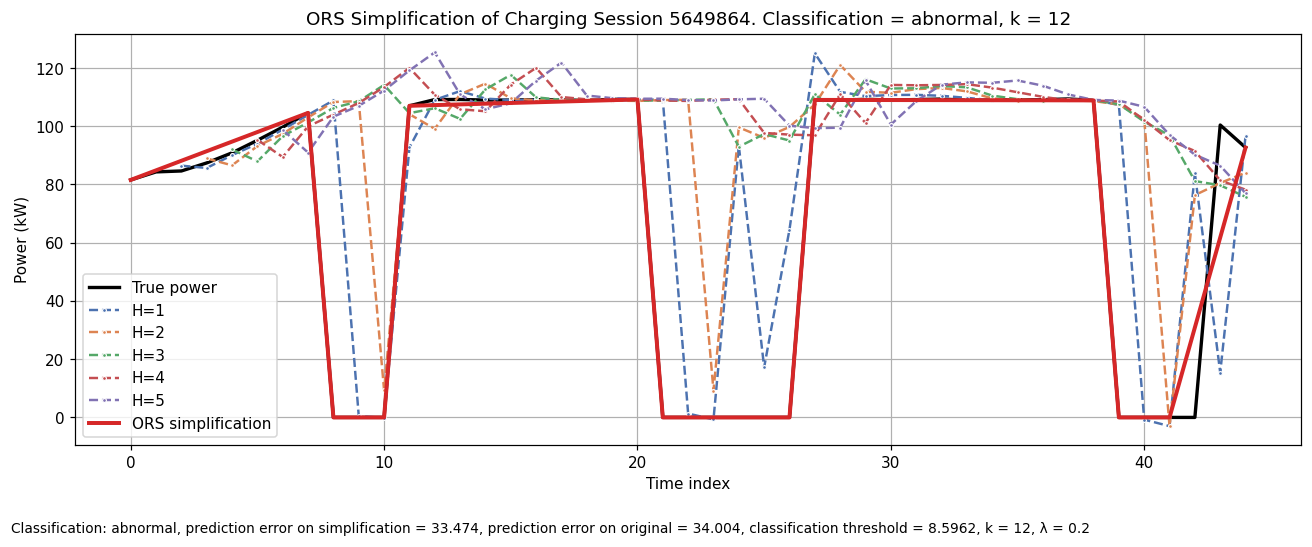

DP-prefix -> k: 12 obj: 38.51190


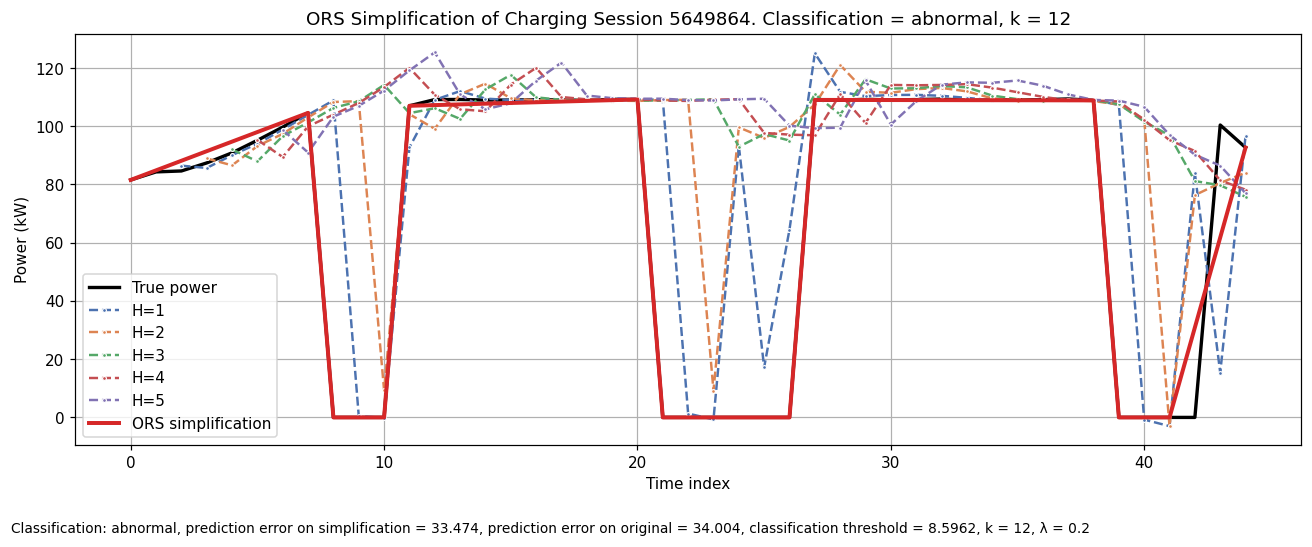

RDP -> k: 15 obj: 48.77515


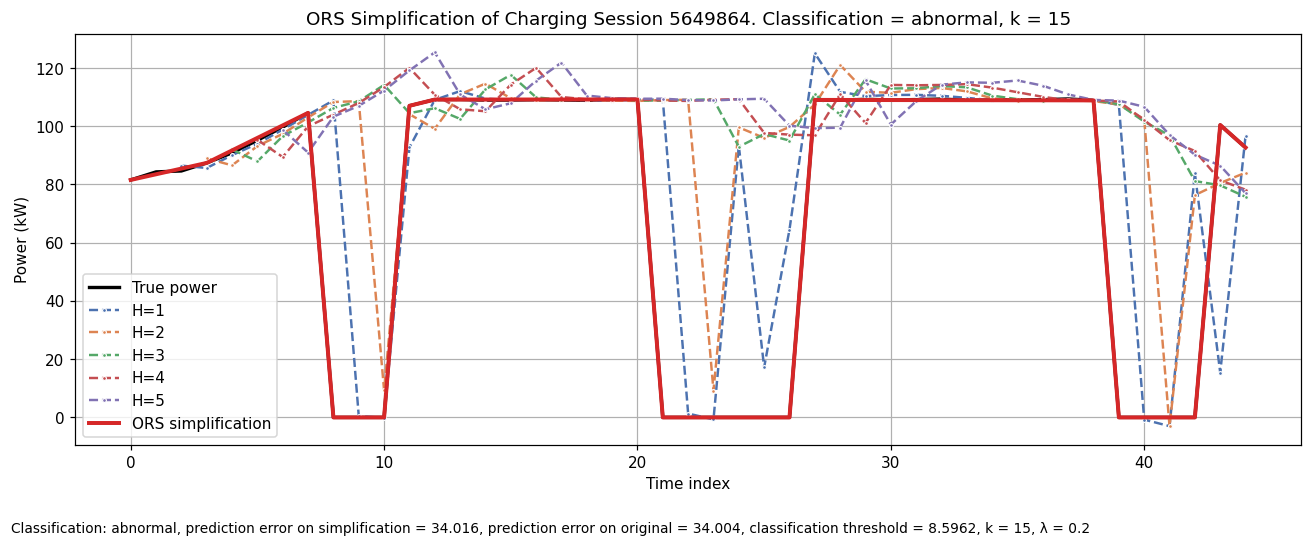

In [ ]:
base_lbl, base_err, _ = base_label_from_bundle(bundle_test,
    power_scaler=power_scaler, soc_scaler=soc_scaler,
    idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
    power_weight=POWER_WEIGHT, decay_lambda=LAMBDA_DECAY,
    t_min_eval=p_vanilla.t_min_eval, threshold=MRC_THRESHOLD)

for tag, res in [("DP-vanilla", res_vanilla), ("DP-prefix", res_fast), ("RDP", res_rdp)]:
    print(tag, "-> k:", res["k"], "obj:", f"{res['obj']:.5f}")
    fig, ax = plot_raw_pred_simp_session(bundle_test, power_scaler, soc_scaler,
        idx_power_inp, idx_soc_inp,
        res['sts'], session_id=bundle_test.session_id,
        k=res['k'], threshold=MRC_THRESHOLD,
        simp_error=res['err'], orig_error=base_err, label=res['label'],
        decay_lambda=LAMBDA_DECAY, t_min_eval=p_vanilla.t_min_eval)
    plt.show()


## 3 - Interactive ORS Explorer

In [7]:
# ---- 1) macro-rmse baseline (original class) ----
# uses same decay/threshold logic as in the AD notebook so the "original classification" is consistent
# set these to match your chosen defaults
T_MIN_EVAL = 2
LAMBDA_DECAY = 0.2

# compute validation/test macro-rmse and threshold (e.g., 95th percentile on validation)
_df_val_m = compute_session_MRMSE(
    model, val_loader, DEVICE, power_scaler, soc_scaler, POWER_WEIGHT,
    idx_power_inp, idx_soc_inp, T_MIN_EVAL, horizon_weights_decay=LAMBDA_DECAY
)
_df_test_m = compute_session_MRMSE(
    model, test_loader, DEVICE, power_scaler, soc_scaler, POWER_WEIGHT,
    idx_power_inp, idx_soc_inp, T_MIN_EVAL, horizon_weights_decay=LAMBDA_DECAY
)
MRC_THRESHOLD = percentile_threshold(np.sort(_df_val_m["error"].to_numpy()), pct_thr=95.0)
print(MRC_THRESHOLD)

_cls_test = classify_by_threshold(_df_test_m, threshold=MRC_THRESHOLD)  # adds 'label' column
# convenience maps
_sid2len = dict(zip(_df_test_m["charging_id"].astype(int), _df_test_m["length"].astype(int)))
_sid2err = dict(zip(_df_test_m["charging_id"].astype(int), _df_test_m["error"].astype(float)))

# ---- 2) lightweight caches ----

@lru_cache(maxsize=2048)
def _bundle_for_sid(sid: int):
    # cached bundle with stored preds; plotting + macro-rmse reuse this
    return fetch_session_preds_bundle(
        model, test_loader, device=DEVICE,
        power_scaler=power_scaler, soc_scaler=soc_scaler,
        idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
        batch_index=None, sample_index=None, session_id=int(sid)
    )

@lru_cache(maxsize=1024)
def _ors_cached(sid: int, stage1_mode: str, stage2_err_metric: str,
                alpha: float, beta: float, gamma: float,
                R: int, epsilon_value: float, q: int, stage1_candidates: int,
                min_k: int, max_k: int, epsilon_mode: str = "fraction") -> dict:
    # keep key small & hashable; bundle stays in separate cache
    params = ORSParams(
        stage1_mode=stage1_mode, stage2_err_metric=stage2_err_metric,
        dp_alpha=float(alpha), beta=float(beta), gamma=float(gamma),
        R=int(R), epsilon_mode=epsilon_mode, epsilon_value=float(epsilon_value),
        dp_q=int(q), rdp_stage1_candidates=int(stage1_candidates),
        min_k=int(min_k), max_k=int(max_k), t_min_eval=T_MIN_EVAL, anchor_endpoints="last",
    )
    b = _bundle_for_sid(int(sid))
    return ors(b, model, params,
               power_scaler=power_scaler, soc_scaler=soc_scaler,
               idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
               power_weight=POWER_WEIGHT, decay_lambda=LAMBDA_DECAY,
               threshold=MRC_THRESHOLD)


# --- layout + widgets for the ORS explorer ---
# Calculate figure width in pixels so that widgets UI width matches the plot width
_FIG_W_IN = 12.0
_FIG_DPI  = 110
_CONTAINER_W = f"{int(_FIG_W_IN * _FIG_DPI)}px"

# 1) widgets (updated ranges/steps)
# top-left: classification
w_class = widgets.ToggleButtons(
    options=[("Normal", "normal"), ("Abnormal", "abnormal")],
    value="abnormal", description="Classification", button_style=""
)

# row1 col2: index slider (session selector)
w_index = widgets.IntSlider(min=0, max=0, step=1, value=0, description="Index", continuous_update=False)

# row1 col3: alpha
w_alpha = widgets.FloatSlider(
    min=0.0, max=0.01, step=0.0001, value=0.01,
    description="α", readout=True, readout_format=".4f",
    continuous_update=False,
    style={"description_width": "auto"},
)

# row1 col4: epsilon (explicit readout + room so it shows)
w_eps = widgets.FloatSlider(
    min=0.0, max=1.0, step=0.01, value=0.30,
    description="ε (frac)", readout=True, readout_format=".2f",
    continuous_update=False,
    style={"description_width": "auto"},
)

# row2 col1: stage-1 candidates mode
w_stage1 = widgets.ToggleButtons(options=[("DP", "dp"), ("DP_prefix", "dp_prefix"), ("RDP", "rdp")],
                                 value="rdp", description="Candidates")

# row2 col2: session id + metrics to the right
w_sid = widgets.Combobox(placeholder="Session ID…", options=[], ensure_option=False,
                         description="Session ID", layout=Layout(width="220px"))
sid_info = widgets.HTML(value="", layout=Layout(margin="24px 0 0 8px"))  # shows “| err=… | T=…”
w_sid_box = widgets.HBox([w_sid, sid_info], layout=Layout(align_items="center"))

w_beta = widgets.FloatSlider(
    min=0.0, max=10.0, step=0.05, value=3.0,
    description="β", readout=True, readout_format=".2f",
    continuous_update=False, style={"description_width": "auto"},
)

# row2 col4: R
w_R     = widgets.IntText(value=1000, description="R", layout=Layout(width="160px"))

# row3 col1: selection metric
w_metric = widgets.ToggleButtons(options=[("L2", "l2"), ("RMSE", "mrmse")],
                                 value="l2", description="Selection")

# row3 col2: length range
w_len = widgets.IntRangeSlider(min=8, max=60, step=1, value=(8, 60),
                               description="Length ℓ", continuous_update=False)

# row3 col3: gamma
w_gamma = widgets.FloatSlider(
    min=0.0, max=1.0, step=0.001, value=0.01,
    description="γ", readout=True, readout_format=".3f",
    continuous_update=False, style={"description_width": "auto"},
)

# row3 col4: q
w_q     = widgets.IntText(value=250,  description="q", layout=Layout(width="160px"))

# row4 col1/2: actions
w_compute = widgets.Button(description="Compute", button_style="primary", icon="gear",
                           layout=Layout(width="180px"))
w_reset   = widgets.Button(description="Reset filters", button_style="", icon="refresh",
                           layout=Layout(width="180px"))

# row4 col3: k-range
w_k = widgets.IntRangeSlider(min=1, max=60, step=1, value=(1, 15), description="k-range")

# row4 col4: n_candidates (10..500, step 10)
w_ncand = widgets.IntSlider(min=10, max=500, step=10, value=10, description="n_candidates")

# status + plot
box_status = widgets.HTML("")
out_plot = widgets.Output()

# 2) helper wiring (re-use your existing functions; only diffs are where we update sid_info)

def _filter_sids(orig_label: str, Lmin: int, Lmax: int) -> list[int]:
    df = _cls_test[_cls_test["label"] == orig_label].copy()
    df = df[(df["length"] >= Lmin) & (df["length"] <= Lmax)]
    df = df.sort_values("error", ascending=False).reset_index(drop=True)
    return df["charging_id"].astype(int).tolist()

def _sid_metrics_html(sid: int | None) -> str:
    if sid is None: 
        return ""
    e = _sid2err.get(int(sid), float("nan"))
    L = _sid2len.get(int(sid), None)
    return f"<span style='opacity:.8'>&nbsp;|&nbsp;err=<b>{e:.4f}</b>&nbsp;|&nbsp;T=<b>{L}</b></span>"

def _refresh_sid_list(*_):
    Lmin, Lmax = w_len.value
    sids = _filter_sids(w_class.value, Lmin, Lmax)
    w_index.max = max(0, len(sids) - 1)
    if w_index.value > w_index.max:
        w_index.value = 0
    # combobox shows only ids now (no metrics in the text)
    w_sid.options = [str(s) for s in sids]
    cur_sid = sids[w_index.value] if sids else None
    w_sid.value = str(cur_sid) if cur_sid is not None else ""
    sid_info.value = _sid_metrics_html(cur_sid)
    return sids

def _sid_from_controls() -> int | None:
    sids = _filter_sids(w_class.value, *w_len.value)
    if not sids:
        return None
    # if user typed an id, prefer that
    try:
        typed = int(str(w_sid.value).strip())
        if typed in sids:
            w_index.value = sids.index(typed)
            sid_info.value = _sid_metrics_html(typed)
            return typed
    except Exception:
        pass
    i = min(max(0, w_index.value), len(sids) - 1)
    sid = sids[i]
    sid_info.value = _sid_metrics_html(sid)
    return sid

def _on_index_change(change):
    if change["name"] == "value":
        sids = _filter_sids(w_class.value, *w_len.value)
        if sids:
            sid = sids[change["new"]]
            w_sid.value = str(sid)
            sid_info.value = _sid_metrics_html(sid)

w_index.observe(_on_index_change, names="value")
for ctl in (w_class, w_len):
    ctl.observe(lambda *_: _refresh_sid_list(), names="value")

def _on_sid_typed(change):
    # update metrics when the combobox content changes
    try:
        sid = int(str(change["new"]).strip())
        if sid in _filter_sids(w_class.value, *w_len.value):
            sid_info.value = _sid_metrics_html(sid)
    except Exception:
        sid_info.value = ""
w_sid.observe(_on_sid_typed, names="value")

def _reset_filters(_btn=None):
    w_class.value = "abnormal"
    w_len.value = (8, 60)
    w_stage1.value = "dp_prefix"
    w_alpha.value = 0.01
    w_beta.value = 3.0
    w_gamma.value = 0.05
    w_eps.value = 0.2
    w_R.value = 2000
    w_q.value = 150
    w_k.value = (1, 15)
    w_ncand.value = 30
    w_metric.value = "l2"
    _refresh_sid_list()
w_reset.on_click(_reset_filters)

# call once to populate
_refresh_sid_list()

# 3) compute callback (unchanged except layout refs)
def _on_compute(_btn):
    sid = _sid_from_controls()
    out_plot.clear_output()
    if sid is None:
        box_status.value = "<b>No sessions</b> match the current filters."
        return

    box_status.value = f"Computing ORS for session <b>{sid}</b> …"
    with out_plot:
        from IPython.display import clear_output
        clear_output(wait=True)
        print("computing…")

    # attempt ORS with current params
    try:
        res = _ors_cached(
            int(sid), w_stage1.value, w_metric.value,
            float(w_alpha.value), float(w_beta.value), float(w_gamma.value),
            int(w_R.value), float(w_eps.value), int(w_q.value), int(w_ncand.value),
            int(w_k.value[0]), int(w_k.value[1]), "fraction"
        )
    except Exception as e:
        box_status.value = (
            f"ORS failed with an exception for session <b>{sid}</b>: "
            f"<code>{type(e).__name__}: {e}</code>"
        )
        return

    # validate dict-like result
    required_keys = {"sts", "k", "err", "frag", "obj", "label"}
    if not isinstance(res, dict) or not required_keys.issubset(set(res.keys())) or res.get("sts") is None:
        # give actionable tips
        tips = (
            "Try loosening constraints: increase ε, widen k-range, raise n_candidates, "
            "or increase R/q. Also check that the session length is compatible with the chosen k-range."
        )
        box_status.value = (
            f"ORS returned no feasible result for session <b>{sid}</b> with the current settings. {tips}"
        )
        with out_plot:
            clear_output(wait=True)
            print("no plot (no feasible simplification).")
        return

    # base label/error for title/caption
    b = _bundle_for_sid(int(sid))
    base_lbl, base_err, _ = base_label_from_bundle(
        b, power_scaler=power_scaler, soc_scaler=soc_scaler,
        idx_power_inp=idx_power_inp, idx_soc_inp=idx_soc_inp,
        power_weight=POWER_WEIGHT, decay_lambda=LAMBDA_DECAY,
        t_min_eval=T_MIN_EVAL, threshold=MRC_THRESHOLD
    )

    # draw plot
    with out_plot:
        clear_output(wait=True)
        fig, ax = plot_raw_pred_simp_session(
            b, power_scaler, soc_scaler, idx_power_inp, idx_soc_inp,
            res["sts"], session_id=int(sid),
            k=res["k"], threshold=MRC_THRESHOLD,
            simp_error=res["err"], orig_error=base_err,
            label=res["label"], decay_lambda=LAMBDA_DECAY, t_min_eval=T_MIN_EVAL
        )
        plt.show()
        print(f"Simplicity (k): {res['k']} segments")

    box_status.value = (
        f"Done. ORS label: <b>{res['label']}</b>, "
        f"error={res['err']:.4f}, frag={res['frag']:.4f}, obj={res['obj']:.4f}"
    )

w_compute.on_click(_on_compute)

# Empty space widgets for alignment
_sp1 = widgets.Label(value="")
_sp2 = widgets.Label(value="")

# 4) grid layout (4x4) + full-width status & plot
grid = widgets.GridBox(
    children=[
        # row1
        w_class,        w_index,   w_alpha,  w_eps,
        # row2
        w_stage1,       w_sid_box, w_beta,   w_ncand,
        # row3
        w_metric,       w_len,     w_gamma,  w_q,
        # row4
        _sp1,      _sp2,   w_k,      w_R,
    ],
    layout=Layout(
        width=_CONTAINER_W,
        grid_template_columns="20% 30% 25% 25%",
        grid_template_rows="auto auto auto auto",
        grid_gap="0px 4px",
        align_items="center",
    )
)

actions_row = HBox(
    [w_compute, w_reset],
    layout=Layout(width=_CONTAINER_W, justify_content="flex-start", gap="8px")
)

ui = widgets.VBox(
    [grid, actions_row, box_status, out_plot],
    layout=Layout(width=_CONTAINER_W)
)

display(ui)


8.9938


Press "Compute" to plot an ORS simplification with the specified parameters. 